## **U2** Procesamiento de Imágenes - Análisis de Rendimiento


**Students:**
- Chay Koyoc Jorge Ramiro
- Ángeles Alejandra Cruz Legorreta
- Brad Robles García

**Course:** High Performance Computing

**Professor:** José Francisco Pérez Alcocer

**School:** Universidad Politécnica de Yucatán  

**Date:** March 13th, 2026

In [ ]:
import matplotlib.pyplot as plt
from google.colab import drive
import numpy as np
import time
import math
import cv2
import os

%load_ext cython

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Carga de Imágenes.


In [ ]:
directory = '/content/drive/MyDrive/EA2-Images_Processing'

# 4. Construir las rutas y cargar las imágenes (forzando escala de grises a 2D)
img1 = cv2.imread(os.path.join(directory, 'Polinesios.jpeg'), cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread(os.path.join(directory, 'imagen_dura.png'), cv2.IMREAD_GRAYSCALE)
img3 = cv2.imread(os.path.join(directory, 'choso.jpg'), cv2.IMREAD_GRAYSCALE)

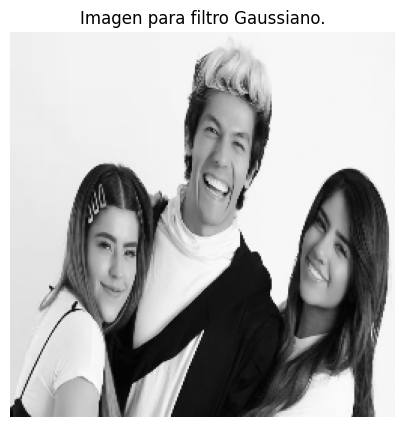

In [ ]:
img1 = cv2.resize(img1, (256,256))
plt.figure(figsize=(5,5))
plt.imshow(img1, cmap='gray')
plt.title('Imagen para filtro Gaussiano.')
plt.axis('off')
plt.show()

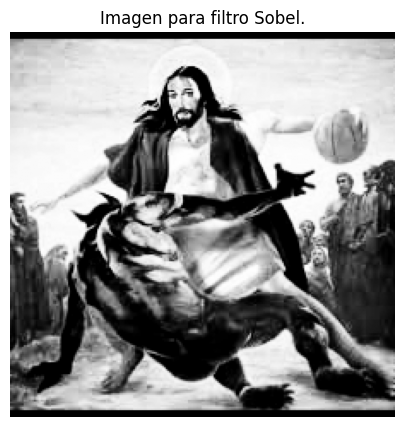

In [ ]:
plt.figure(figsize=(5, 5))
plt.imshow(img2, cmap='gray')
plt.title('Imagen para filtro Sobel.')
plt.axis('off')
plt.show()

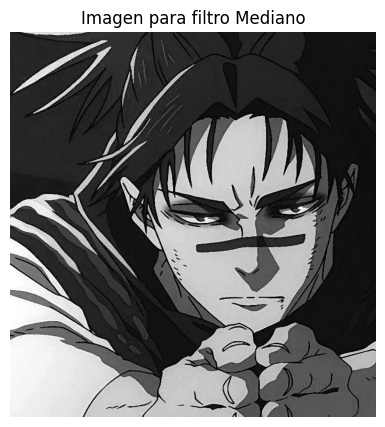

In [ ]:
plt.figure(figsize=(5, 5))
plt.imshow(img3, cmap='gray')
plt.title('Imagen para filtro Mediano')
plt.axis('off')
plt.show()

## 2. Filtro Gaussiano

In [ ]:
def gaussian_python(img):

    kernel = np.array([
    [1,4,6,4,1],
    [4,16,24,16,4],
    [6,24,36,24,6],
    [4,16,24,16,4],
    [1,4,6,4,1]
    ], dtype=float)

    kernel = kernel / kernel.sum()

    k = kernel.shape[0]
    pad = k // 2

    padded = np.pad(img, pad, mode='constant')
    result = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):

            value = 0

            for m in range(k):
                for n in range(k):

                    value += kernel[m][n] * padded[i+m][j+n]

            result[i][j] = value

    return result

In [ ]:
# Visualizar resultado de Python Puro
start = time.perf_counter()
img_python = gaussian_python(img1)
end = time.perf_counter()
time_python = end - start

print("Tiempo Python puro:", time_python)

Tiempo Python puro: 1.5275232089999804


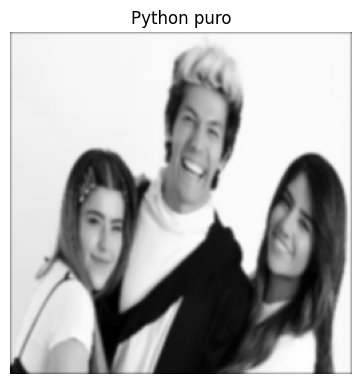

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_python, cmap='gray')
plt.title("Python puro")
plt.axis("off")

plt.show()

In [ ]:
from scipy.signal import convolve2d
import numpy as np
import time

def gaussian_numpy(img):

    img = img.astype(float)

    kernel = np.array([
    [1,4,6,4,1],
    [4,16,24,16,4],
    [6,24,36,24,6],
    [4,16,24,16,4],
    [1,4,6,4,1]
    ], dtype=float)

    kernel = kernel / kernel.sum()

    result = convolve2d(img, kernel, mode='same', boundary='symm')

    return result

In [ ]:
# Visualizar resultado de NumPy
start = time.perf_counter()
img_numpy = gaussian_numpy(img1)
end = time.perf_counter()
time_numpy = end - start

print("Tiempo NumPy:", time_numpy)

Tiempo NumPy: 0.01315856700000495


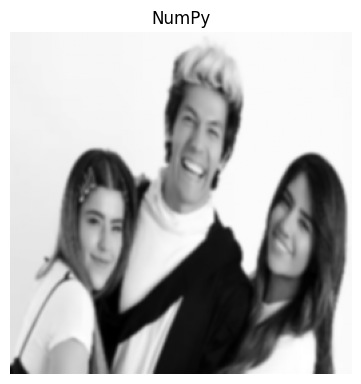

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,2)
plt.imshow(img_numpy, cmap='gray')
plt.title("NumPy")
plt.axis("off")

plt.show()

In [ ]:
%%cython

import numpy as np
cimport numpy as np

def gaussian_cython(np.ndarray[np.float64_t, ndim=2] img):

    cdef np.ndarray[np.float64_t, ndim=2] kernel = np.array([
        [1,4,6,4,1],
        [4,16,24,16,4],
        [6,24,36,24,6],
        [4,16,24,16,4],
        [1,4,6,4,1]
    ], dtype=np.float64)

    kernel = kernel / kernel.sum()

    cdef int i, j, m, n
    cdef int k = kernel.shape[0]
    cdef int pad = k // 2
    cdef double value

    cdef np.ndarray[np.float64_t, ndim=2] padded = np.pad(img, pad)
    cdef np.ndarray[np.float64_t, ndim=2] result = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):

            value = 0.0

            for m in range(k):
                for n in range(k):

                    value += kernel[m, n] * padded[i+m, j+n]

            result[i, j] = value

    return result

Content of stderr:
In file included from /usr/local/lib/python3.12/dist-packages/numpy/_core/include/numpy/ndarraytypes.h:1909,
                 from /usr/local/lib/python3.12/dist-packages/numpy/_core/include/numpy/ndarrayobject.h:12,
                 from /usr/local/lib/python3.12/dist-packages/numpy/_core/include/numpy/arrayobject.h:5,
                 from /root/.cache/ipython/cython/_cython_magic_c859dc427180d5a3679194908183bee4979d31d9.c:1250:
/usr/local/lib/python3.12/dist-packages/numpy/_core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: #warning "Using deprecated NumPy API, disable it with " "#define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION" [-Wcpp]
   17 | #warning "Using deprecated NumPy API, disable it with " \
      |  ^~~~~~~

In [ ]:
# Medición de tiempo y visualización de resultado de Cython
start = time.perf_counter()

img_cython = gaussian_cython(img1.astype(np.float64))

end = time.perf_counter()

time_cython = end - start

print("Tiempo Cython:", time_cython)

Tiempo Cython: 0.007603904999996303


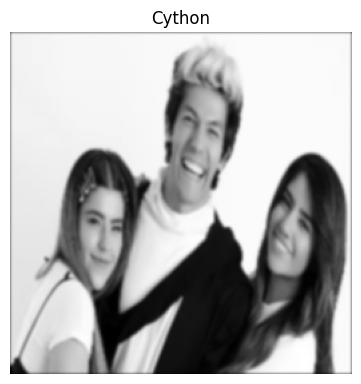

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,3)
plt.imshow(img_cython, cmap='gray')
plt.title("Cython")
plt.axis("off")

plt.show()

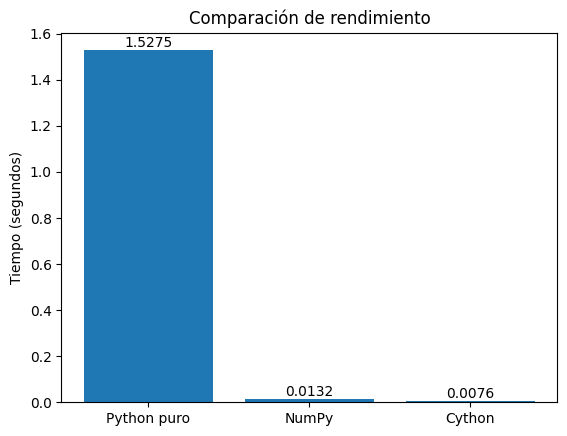

In [ ]:
#Comparativa de cada modelo
times = [time_python, time_numpy, time_cython]
labels = ["Python puro", "NumPy", "Cython"]

plt.figure()

bars = plt.bar(labels, times)

plt.ylabel("Tiempo (segundos)")
plt.title("Comparación de rendimiento")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             round(yval,4),
             ha='center',
             va='bottom')

plt.show()

## 3. Filtro Sobel

Python puro.

In [ ]:
def sobel_python_puro(imagen):
    # Obtener las dimensiones de la imagen
    filas = len(imagen)
    columnas = len(imagen[0])

    # Crear una matriz vacía (lista de listas) llena de ceros para el resultado
    resultado = [[0] * columnas for _ in range(filas)]

    # Definir los kernels de Sobel
    Kx = [[-1, 0, 1],
          [-2, 0, 2],
          [-1, 0, 1]]

    Ky = [[-1, -2, -1],
          [0, 0, 0],
          [1, 2, 1]]

    for i in range(1, filas - 1):
        for j in range(1, columnas - 1):
            gx = 0
            gy = 0

            # Aplicar la convolución 3x3 al vecindario del píxel
            for ki in range(3):
                for kj in range(3):
                    pixel = imagen[i + ki - 1][j + kj - 1]
                    gx += pixel * Kx[ki][kj]
                    gy += pixel * Ky[ki][kj]

            # Calcular la magnitud del gradiente
            magnitud = math.sqrt(gx**2 + gy**2)

            # Limitar el valor máximo a 255
            if magnitud > 255:
                magnitud = 255

            resultado[i][j] = int(magnitud)

    return resultado

# Convertimos el array a una lista de listas nativa de Python para que sea puro
img2_lista = img2.tolist()

print("Ejecutando Filtro Sobel en Python Puro")
inicio = time.time()
resultado_py = sobel_python_puro(img2_lista)
tiempo_py = time.time() - inicio

print(f"Tiempo de ejecución (Python Puro): {tiempo_py:.4f} segundos")

Ejecutando Filtro Sobel en Python Puro
Tiempo de ejecución (Python Puro): 0.2027 segundos


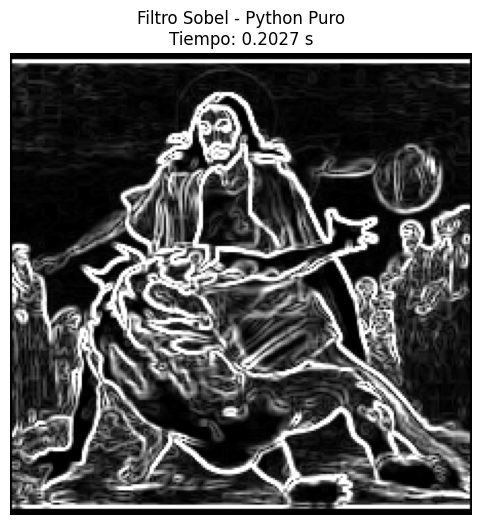

In [ ]:
# Convertimos de vuelta a array solo para poder graficar con matplotlib
plt.figure(figsize=(6, 6))
plt.imshow(np.array(resultado_py), cmap='gray')
plt.title(f'Filtro Sobel - Python Puro\nTiempo: {tiempo_py:.4f} s')
plt.axis('off')
plt.show()

Numpy.

In [ ]:
def sobel_numpy(imagen):
    # Convertimos la imagen a un array de float64 para evitar desbordamientos
    # matemáticos al calcular los gradientes y elevar al cuadrado
    img_arr = np.array(imagen, dtype=np.float64)

    # Obtenemos las dimensiones
    filas, columnas = img_arr.shape

    # Creamos matrices de ceros para almacenar los gradientes en X e Y
    gx = np.zeros((filas, columnas), dtype=np.float64)
    gy = np.zeros((filas, columnas), dtype=np.float64)

    # En lugar de iterar, desplazamos la matriz de la imagen entera y la multiplicamos
    # por los valores correspondientes del kernel de Sobel.
    # Kernel X
    gx[1:-1, 1:-1] = (
        -1 * img_arr[0:-2, 0:-2] + 1 * img_arr[0:-2, 2:] +
        -2 * img_arr[1:-1, 0:-2] + 2 * img_arr[1:-1, 2:] +
        -1 * img_arr[2:, 0:-2]   + 1 * img_arr[2:, 2:]
    )

    # Kernel Y
    gy[1:-1, 1:-1] = (
        -1 * img_arr[0:-2, 0:-2] - 2 * img_arr[0:-2, 1:-1] - 1 * img_arr[0:-2, 2:] +
         1 * img_arr[2:, 0:-2]   + 2 * img_arr[2:, 1:-1]   + 1 * img_arr[2:, 2:]
    )

    # Calcular la magnitud del gradiente matricialmente
    # Fórmula: G = sqrt(Sx^2 + Sy^2)
    magnitud = np.sqrt(gx**2 + gy**2)

    # Recortar los valores que superen 255 y convertir de vuelta a enteros de 8 bits
    magnitud = np.clip(magnitud, 0, 255).astype(np.uint8)

    return magnitud

print("Ejecutando Filtro Sobel con NumPy")
inicio = time.time()
resultado_np = sobel_numpy(img2)
tiempo_np = time.time() - inicio
print(f"Tiempo de ejecución (NumPy): {tiempo_np:.6f} segundos")

Ejecutando Filtro Sobel con NumPy
Tiempo de ejecución (NumPy): 0.004794 segundos


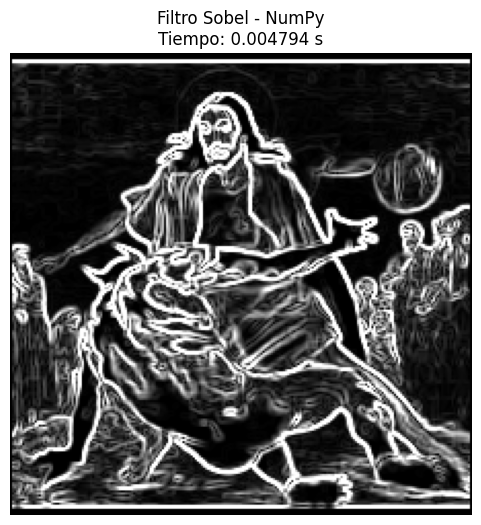

In [ ]:
plt.figure(figsize=(6, 6))
plt.imshow(resultado_np, cmap='gray')
plt.title(f'Filtro Sobel - NumPy\nTiempo: {tiempo_np:.6f} s')
plt.axis('off')
plt.show()

Numpy + Cython.

In [ ]:
%%cython -a
import numpy as np
cimport numpy as np
cimport cython
from libc.math cimport sqrt

# Desactivamos las validaciones de límites de Python para máxima velocidad en C
@cython.boundscheck(False)
@cython.wraparound(False)
def sobel_cython(unsigned char[:, :] image):
    # Declaración estática de variables
    cdef int filas = image.shape[0]
    cdef int columnas = image.shape[1]

    # Creamos la matriz de resultado vacía y la tipamos
    cdef np.ndarray[np.uint8_t, ndim=2] resultado_np = np.zeros((filas, columnas), dtype=np.uint8)
    cdef unsigned char[:, :] resultado = resultado_np

    cdef int i, j
    cdef double gx, gy, magnitud

    # Estos bucles for ahora se ejecutarán a la velocidad de C, no de Python
    for i in range(1, filas - 1):
        for j in range(1, columnas - 1):

            # Aplicamos el Kernel X
            gx = (-1 * image[i-1, j-1] + 1 * image[i-1, j+1] +
                  -2 * image[i,   j-1] + 2 * image[i,   j+1] +
                  -1 * image[i+1, j-1] + 1 * image[i+1, j+1])

            # Aplicamos el Kernel Y
            gy = (-1 * image[i-1, j-1] - 2 * image[i-1, j] - 1 * image[i-1, j+1] +
                   1 * image[i+1, j-1] + 2 * image[i+1, j] + 1 * image[i+1, j+1])

            # Calculamos la magnitud usando la función sqrt de la librería math de C
            magnitud = sqrt(gx*gx + gy*gy)

            if magnitud > 255:
                magnitud = 255

            resultado[i, j] = <unsigned char>magnitud

    return resultado_np

Content of stderr:
In file included from /usr/local/lib/python3.12/dist-packages/numpy/_core/include/numpy/ndarraytypes.h:1909,
                 from /usr/local/lib/python3.12/dist-packages/numpy/_core/include/numpy/ndarrayobject.h:12,
                 from /usr/local/lib/python3.12/dist-packages/numpy/_core/include/numpy/arrayobject.h:5,
                 from /root/.cache/ipython/cython/_cython_magic_f94cb2dbe82bb1aa21b5ccbb3d47bdef143d65d8.c:1251:
/usr/local/lib/python3.12/dist-packages/numpy/_core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: #warning "Using deprecated NumPy API, disable it with " "#define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION" [-Wcpp]
   17 | #warning "Using deprecated NumPy API, disable it with " \
      |  ^~~~~~~

Ejecutando Filtro Sobel con Cython
Tiempo de ejecución (Cython): 0.000574 segundos


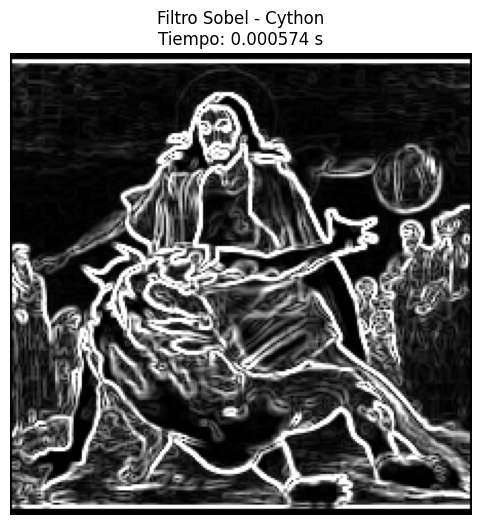

In [ ]:
print("Ejecutando Filtro Sobel con Cython")
# Nos aseguramos de que la imagen sea un array contiguo en memoria del tipo uint8
img2_cy = np.ascontiguousarray(img2, dtype=np.uint8)

inicio = time.time()
# Llamamos a nuestra función compilada en C
resultado_cy = sobel_cython(img2_cy)
tiempo_cy = time.time() - inicio

print(f"Tiempo de ejecución (Cython): {tiempo_cy:.6f} segundos")

# --- Visualización ---
plt.figure(figsize=(6, 6))
plt.imshow(resultado_cy, cmap='gray')
plt.title(f'Filtro Sobel - Cython\nTiempo: {tiempo_cy:.6f} s')
plt.axis('off')
plt.show()

Comparativa de Rendimiento.

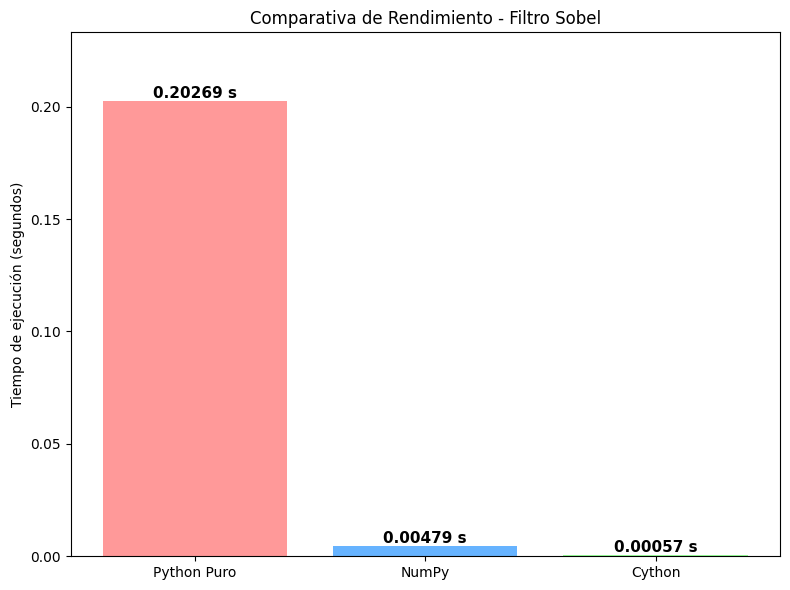

In [ ]:
metodos = ['Python Puro', 'NumPy', 'Cython']
tiempos = [tiempo_py, tiempo_np, tiempo_cy]

plt.figure(figsize=(8, 6))
barras = plt.bar(metodos, tiempos, color=['#ff9999', '#66b3ff', '#99ff99'])

plt.ylabel('Tiempo de ejecución (segundos)')
plt.title('Comparativa de Rendimiento - Filtro Sobel')
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width() / 2.0, yval, f'{yval:.5f} s',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylim(0, max(tiempos) * 1.15)
plt.tight_layout()
plt.show()

## 4. Filtro Mediano

In [ ]:
# Implementación en Python Puro y medición de tiempo
import time
import numpy as np

# Implementación en Python Puro y medición de tiempo
def median_filter_pure(image):
    rows = len(image)
    cols = len(image[0])
    # Crear imagen de salida vacía
    output = [[0 for _ in range(cols)] for _ in range(rows)]

    for i in range(1, rows - 1):
        for j in range(1, cols - 1):
            neighborhood = [
                image[i-1][j-1], image[i-1][j], image[i-1][j+1],
                image[i][j-1],   image[i][j],   image[i][j+1],
                image[i+1][j-1], image[i+1][j], image[i+1][j+1]
            ]
            # Ordenar y tomar el valor central
            neighborhood.sort()
            output[i][j] = neighborhood[4]

    return np.array(output)

# Medición de tiempo
start_time = time.time()
res_pure = median_filter_pure(img3.tolist())
time_pure = time.time() - start_time

print(f"Tiempo Python Puro: {time_pure:.4f} segundos")

Tiempo Python Puro: 0.4379 segundos


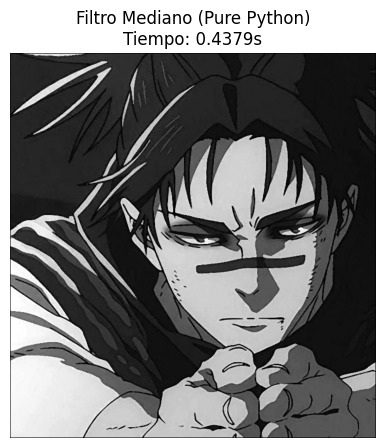

In [ ]:
# Visualizar resultado de Python Puro
plt.figure(figsize=(5, 5))
plt.imshow(res_pure, cmap='gray')
plt.title(f'Filtro Mediano (Pure Python)\nTiempo: {time_pure:.4f}s')
plt.axis('off')
plt.show()

In [ ]:
def median_filter_numpy(image):
    rows, cols = image.shape
    # Creamos una pila de 9 versiones de la imagen desplazadas
    layers = []
    for di in [-1, 0, 1]:
        for dj in [-1, 0, 1]:
            layers.append(np.roll(np.roll(image, di, axis=0), dj, axis=1))

    # Calculamos la mediana a través de todas las capas
    stacked = np.stack(layers, axis=0)
    return np.median(stacked, axis=0).astype(np.uint8)

# Medición de tiempo
start_time = time.time()
res_numpy = median_filter_numpy(img3)
time_numpy = time.time() - start_time

print(f"Tiempo NumPy: {time_numpy:.4f} segundos")

Tiempo NumPy: 0.0710 segundos


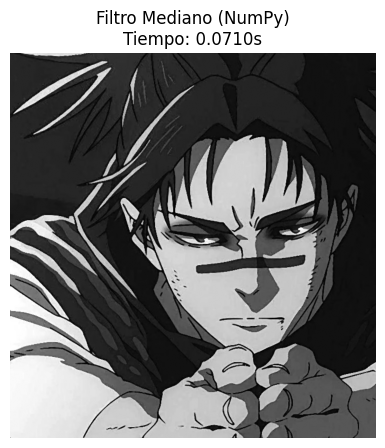

In [ ]:
plt.figure(figsize=(5, 5))
plt.imshow(res_numpy, cmap='gray')
plt.title(f'Filtro Mediano (NumPy)\nTiempo: {time_numpy:.4f}s')
plt.axis('off')
plt.show()

In [ ]:
%%cython -a
import numpy as np
cimport numpy as cnp
cimport cython

@cython.boundscheck(False)
@cython.wraparound(False)
def median_filter_cython(cnp.uint8_t[:, :] image):
    cdef int rows = image.shape[0]
    cdef int cols = image.shape[1]
    cdef cnp.uint8_t[:, :] output = np.zeros((rows, cols), dtype=np.uint8)
    cdef int i, j, m, n
    cdef int[9] window

    for i in range(1, rows - 1):
        for j in range(1, cols - 1):
            window[0] = image[i-1, j-1]; window[1] = image[i-1, j]; window[2] = image[i-1, j+1]
            window[3] = image[i, j-1];   window[4] = image[i, j];   window[5] = image[i, j+1]
            window[6] = image[i+1, j-1]; window[7] = image[i+1, j]; window[8] = image[i+1, j+1]

            # Ordenamiento simple
            for m in range(9):
                for n in range(m + 1, 9):
                    if window[m] > window[n]:
                        window[m], window[n] = window[n], window[m]

            output[i, j] = window[4]

    return np.asarray(output)

Content of stderr:
In file included from /usr/local/lib/python3.12/dist-packages/numpy/_core/include/numpy/ndarraytypes.h:1909,
                 from /usr/local/lib/python3.12/dist-packages/numpy/_core/include/numpy/ndarrayobject.h:12,
                 from /usr/local/lib/python3.12/dist-packages/numpy/_core/include/numpy/arrayobject.h:5,
                 from /root/.cache/ipython/cython/_cython_magic_20c58db0ad6271ddfe1dff688839da812a97a8b3.c:1255:
/usr/local/lib/python3.12/dist-packages/numpy/_core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: #warning "Using deprecated NumPy API, disable it with " "#define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION" [-Wcpp]
   17 | #warning "Using deprecated NumPy API, disable it with " \
      |  ^~~~~~~

In [ ]:
# Medición de tiempo y visualización de resultado de Cython
start_time = time.time()
res_cython = median_filter_cython(img3)
time_cython = time.time() - start_time

print(f"Tiempo Cython: {time_cython:.4f} segundos")

Tiempo Cython: 0.0778 segundos


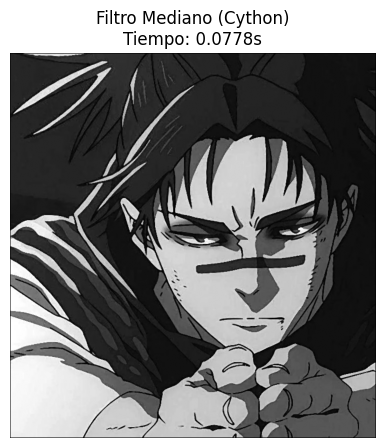

In [ ]:
plt.figure(figsize=(5, 5))
plt.imshow(res_cython, cmap='gray')
plt.title(f'Filtro Mediano (Cython)\nTiempo: {time_cython:.4f}s')
plt.axis('off')
plt.show()

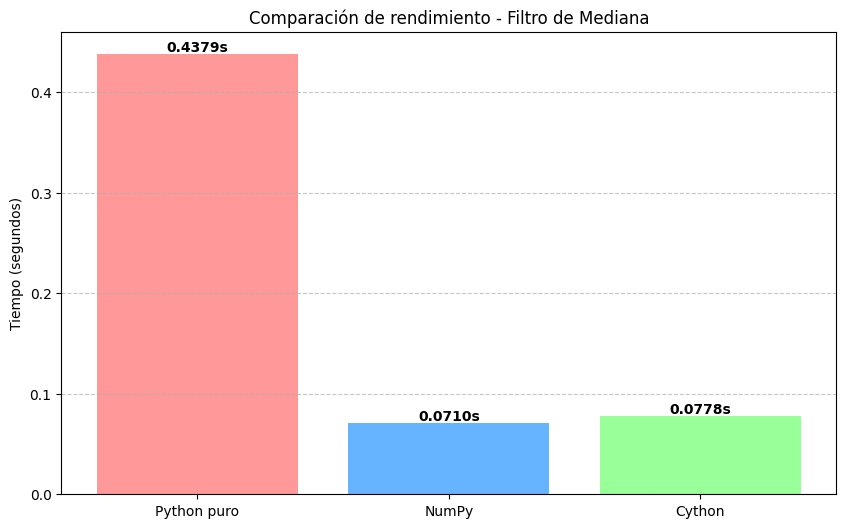

In [46]:
times = [time_pure, time_numpy, time_cython]
labels = ["Python puro", "NumPy", "Cython"]

plt.figure(figsize=(10, 6))

bars = plt.bar(labels, times, color=['#ff9999','#66b3ff','#99ff99'])

plt.ylabel("Tiempo (segundos)")
plt.title("Comparación de rendimiento - Filtro de Mediana")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             f'{yval:.4f}s',
             ha='center',
             va='bottom',
             fontsize=10,
             fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Análisis de Tiempos de Ejecución

Al evaluar los tres enfoques de procesamiento (Python Puro, NumPy y NumPy + Cython), se observa una mejora drástica y progresiva en los tiempos de ejecución. Tomando como caso de estudio el Filtro Sobel, la implementación iterativa nativa tardó aproximadamente 202 milisegundos. Al aplicar la vectorización con NumPy, el tiempo se redujo a 4.8 milisegundos. Finalmente, la compilación directa mediante Cython logró un tiempo de ejecución de apenas 0.57 milisegundos (¡más de 300 veces más rápido que la base iterativa!). Esta tendencia subraya cómo el procesamiento de grandes volúmenes de datos (como las matrices bidimensionales de las imágenes) sufre un cuello de botella severo debido a la naturaleza interpretada de Python.

# Conclusión

Para las arquitecturas modernas de procesamiento, aprovechar la vectorización de NumPy resulta ser la herramienta estándar y el enfoque más productivo. Las optimizaciones extremas como Cython deben reservarse estrictamente para cuellos de botella específicos donde los milisegundos ahorrados justifiquen la complejidad del código.